In [1]:
import loica as lc
import flapjack as fj
import matplotlib.pyplot as plt
import numpy as np
import getpass
from itertools import permutations 
import pandas as pd
import seaborn as sns

In [2]:
user = input()
passwd = getpass.getpass()
#flap = fj.flapjack.Flapjack('localhost:8000')
flap = fj.flapjack.Flapjack('flapjack.rudge-lab.org:8000')
flap.log_in(username=user, password=passwd)

In [3]:
study = flap.get('study', name='Repressilator behavior')
if len(study)==0:
    study = flap.create('study', name='Repressilator behavior', description='Behavior of repressilator with different genetic circuits designs')
media = flap.get('media', name='M9Glucose')
if len(media)==0:
    media = flap.create('media', name='M9Glucose', description='induction')
strain = flap.get('strain', name='E.coli T7')
if len(strain)==0:
    strain = flap.create('strain', name='E.coli T7', description='E.coli T7')    
gfps = flap.get('signal', name='GFP')
if len(gfps)==0:
    gfps = flap.create('signal', name='GFP', color='green', description='fluorescent')
biomass_signal = flap.create('signal', name='OD', color='black', description='biomass')

## Regulators

from https://www.embopress.org/doi/full/10.15252/msb.20199401 

In [7]:
#Regulators
amer = lc.Regulator(name='AmeR', degradation_rate=1)
lmera = lc.Regulator(name='LmerA', degradation_rate=1)
amtr = lc.Regulator(name='AmtR', degradation_rate=1)
hlyllr = lc.Regulator(name='HlyllR', degradation_rate=1)
phif = lc.Regulator(name='PhiF', degradation_rate=1)
srpr = lc.Regulator(name='SrpR', degradation_rate=1)
beti = lc.Regulator(name='BetI', degradation_rate=1)
bm3r1 = lc.Regulator(name='BM3R1', degradation_rate=1)
cymr = lc.Regulator(name='CymR', degradation_rate=1)
vanr = lc.Regulator(name='VanR', degradation_rate=1)

In [8]:
NOT_F1_AmeR = ([amer, 4.276875167, 0.289281104, 0.121548379, 1.542139516])
NOT_F2_AmeR = ([amer, 3.468235830, 0.206243141, 0.034613400, 1.314222122])
NOT_N1_LmrA = ([lmera, 1.188165807, 0.077273193, 0.093521178, 1.754564179])
NOT_A1_AmtR = ([amtr, 3.101389402, 0.035221608, 0.047427884, 1.656171138])
NOT_H1_HlyIIR = ([hlyllr, 2.051723191, 0.004353486, 0.130693758, 2.588160165])
NOT_P1_PhlF = ([phif, 6.869075907, 0.004337295, 0.042126721, 3.804263913])
NOT_P2_PhlF = ([phif, 7.480185697, 0.006679767, 0.203849960, 4.481560106])
NOT_P3_PhlF = ([phif, 7.083442096, 0.004656815, 0.116044457, 3.342819362])
NOT_S1_SrpR = ([srpr, 1.365149567, 0.001354520, 0.016906016, 3.095316853])
NOT_S2_SrpR = ([srpr, 3.165616099, 0.002829301, 0.062531512, 2.655303675])
NOT_S3_SrpR = ([srpr, 3.051477031, 0.004054680, 0.087385601, 2.657349101])
NOT_S4_SrpR = ([srpr, 3.161638671, 0.004347046, 0.110327837, 2.654076554])
NOT_E1_BetI = ([beti, 2.797014815, 0.040842627, 0.277844523, 2.880416695])
NOT_B1_BM3R1 = ([bm3r1, 0.574084351, 0.003721745, 0.055519757, 2.888263374])
NOT_B2_BM3R1 = ([bm3r1, 0.480763613, 0.005549518, 0.574115383, 3.842787839])
NOT_B3_BM3R1 = ([bm3r1, 0.579800495, 0.004958926, 0.211950504, 3.085977286])
NOT_C1_CymR = ([cymr, 2.994385285, 0.009785490, 0.100908709, 3.693304378])
NOT_V1_VanR = ([vanr, 6.130938128, 0.043503414, 0.049692514, 2.984652678])

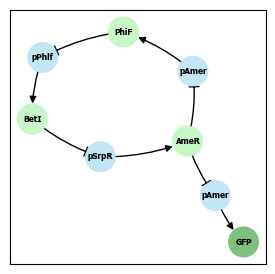

In [9]:
rep = lc.GeneticNetwork(vector=0)

rep.add_regulator([amer, beti, phif])

gfp_rep = lc.Reporter(name='GFP', degradation_rate=0, signal_id=0, color='green')
rep.add_reporter(gfp_rep)

amer_not_beti = lc.Hill1(name='pAmer', input=NOT_F1_AmeR[0], output=[NOT_P2_PhlF[0]], alpha=[NOT_F1_AmeR[1]*1000,NOT_F1_AmeR[2]*1000], K=NOT_F1_AmeR[3]*1000, n=NOT_F1_AmeR[4] )
beti_not_phif = lc.Hill1(name='pPhlf', input=NOT_P2_PhlF[0], output=NOT_E1_BetI[0], alpha=[NOT_P2_PhlF[1]*1000,NOT_P2_PhlF[2]*1000], K=NOT_P2_PhlF[3]*1000, n=NOT_P2_PhlF[4] )
phlf_not_amer = lc.Hill1(name='pSrpR', input=NOT_E1_BetI[0], output=NOT_F1_AmeR[0], alpha=[NOT_E1_BetI[1]*1000,NOT_E1_BetI[2]*1000], K=NOT_E1_BetI[3]*1000, n=NOT_E1_BetI[4])
phlf_not_gfp = lc.Hill1(name='pAmer', input=NOT_F1_AmeR[0], output=gfp_rep, alpha=[NOT_F1_AmeR[1]*1000,NOT_F1_AmeR[2]*1000], K=NOT_F1_AmeR[3]*1000, n=NOT_F1_AmeR[4])
rep.add_operator([amer_not_beti, beti_not_phif, phlf_not_amer, phlf_not_gfp])

plt.figure(figsize=(3.3,3.3), dpi=100)
rep.draw()

In [34]:
def growth_rate(t):
    return lc.gompertz_growth_rate(t, 0.01, 1, 1, 4)

def biomass(t):
    return lc.gompertz(t, 0.01, 1, 1, 4)

metab = lc.SimulatedMetabolism('LOICA metab', biomass, growth_rate)

sample = lc.Sample(genetic_network=rep, 
                metabolism=metab,
                media=0,
                strain=0
               )
assay = lc.Assay([sample], 
              n_measurements=100, 
              interval=0.25,
              name='LOICA repressilator SEED2023',
              description='Simulated repressilator generated by LOICA',
              biomass_signal_id=0
             )
assay.run() #assay.run(nsr=1e-3)

100%|██████████| 100.0/100 [00:00<00:00, 156.12it/s]


<AxesSubplot:xlabel='Time'>

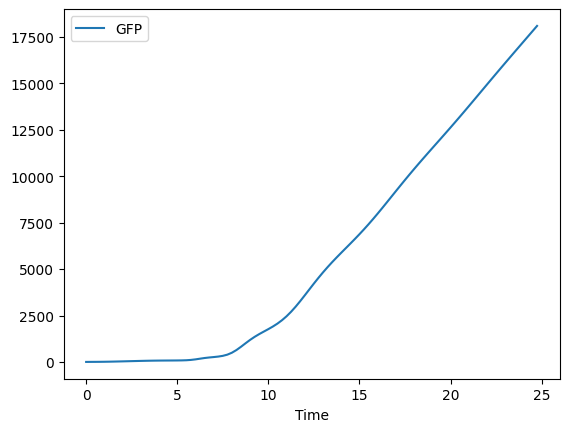

In [35]:
m = assay.measurements
fig,ax = plt.subplots(1,1)
m[m.Signal=='GFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{gfp_rep}')

In [51]:

NOT_F1_AmeR = ([amer, 3.468235830, 0.206243141, 0.034613400, 1.314222122])

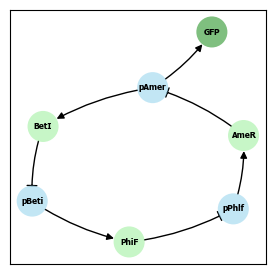

In [27]:
rep = lc.GeneticNetwork(vector=0)

rep.add_regulator([amer, beti, phif])

gfp_rep = lc.Reporter(name='GFP', degradation_rate=0, signal_id=0, color='green')
rep.add_reporter(gfp_rep)

amer_not_beti_gfp = lc.Hill1(name='pAmer', input=NOT_F1_AmeR[0], output=[NOT_E1_BetI[0], gfp_rep], alpha=[NOT_F1_AmeR[1]*1000,NOT_F1_AmeR[2]*1000], K=NOT_F1_AmeR[3]*1000, n=NOT_F1_AmeR[4] )
beti_not_phif = lc.Hill1(name='pBeti', input=NOT_E1_BetI[0], output=NOT_P3_PhlF[0], alpha=[NOT_E1_BetI[1]*1000,NOT_E1_BetI[2]*1000], K=NOT_E1_BetI[3]*1000, n=NOT_E1_BetI[4])
phlf_not_amer = lc.Hill1(name='pPhlf', input=NOT_P3_PhlF[0], output=NOT_F1_AmeR[0], alpha=[NOT_P3_PhlF[1]*1000,NOT_P3_PhlF[2]*1000], K=NOT_P3_PhlF[3]*1000, n=NOT_P3_PhlF[4])
rep.add_operator([amer_not_beti_gfp, beti_not_phif, phlf_not_amer])

plt.figure(figsize=(3.3,3.3), dpi=100)
rep.draw()

In [28]:
def growth_rate(t):
    return lc.gompertz_growth_rate(t, 0.01, 1, 1, 4)

def biomass(t):
    return lc.gompertz(t, 0.01, 1, 1, 4)

metab = lc.SimulatedMetabolism('LOICA metab', biomass, growth_rate)

sample = lc.Sample(genetic_network=rep, 
                metabolism=metab,
                media=0,
                strain=0
               )
assay = lc.Assay([sample], 
              n_measurements=100, 
              interval=0.25,
              name='LOICA repressilator SEED2022',
              description='Simulated repressilator generated by LOICA',
              biomass_signal_id=0
             )
assay.run() #assay.run(nsr=1e-3)

100%|██████████| 100.0/100 [00:00<00:00, 160.58it/s]


<AxesSubplot:xlabel='Time'>

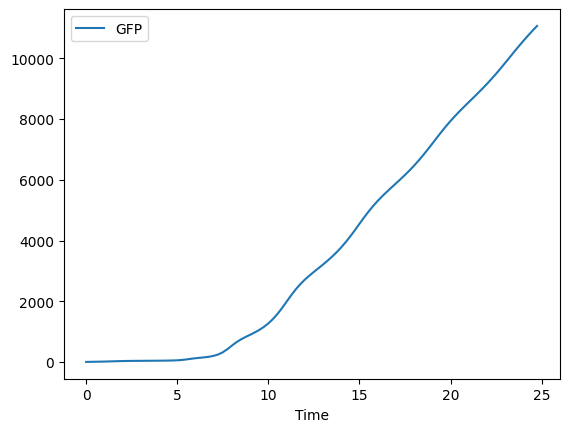

In [29]:
m = assay.measurements
fig,ax = plt.subplots(1,1)
m[m.Signal=='GFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{gfp_rep}')

In [42]:
NOT_F1_AmeR = [amer, 4.276875167, 0.289281104, 0.121548379, 1.542139516]
NOT_E1_BetI = [beti, 2.797014815, 0.040842627, 0.277844523, 2.880416695]


In [46]:
#Cello
NOT_amer_f1 = [amer, 3.8, 0.2, 0.09, 1.4]
NOT_beti_e1 = [beti, 3.8, 0.07, 0.41, 2.4]

In [55]:
perms = []
perm = permutations([NOT_F1_AmeR, 
                     NOT_F2_AmeR, 
                     NOT_N1_LmrA,
                     NOT_A1_AmtR,
                     NOT_H1_HlyIIR,
                     NOT_P1_PhlF,
                     NOT_P2_PhlF,
                     NOT_P3_PhlF,
                     NOT_S1_SrpR,
                     NOT_S2_SrpR,
                     NOT_S3_SrpR,
                     NOT_S4_SrpR,
                     NOT_E1_BetI,
                     NOT_B1_BM3R1,
                     NOT_B2_BM3R1,
                     NOT_B3_BM3R1,
                     NOT_C1_CymR,
                     NOT_V1_VanR],3)  #with a larger list then we can do ([NOT_1, NOT_2, NOT_3],3)
for i in list(perm):  
    perms.append(i) 

print(perms)

[([<loica.geneproduct.Regulator object at 0x7f8362c63ac0>, 3.46823583, 0.206243141, 0.0346134, 1.314222122], [<loica.geneproduct.Regulator object at 0x7f8362c63ac0>, 3.46823583, 0.206243141, 0.0346134, 1.314222122], [<loica.geneproduct.Regulator object at 0x7f8362c63a60>, 1.188165807, 0.077273193, 0.093521178, 1.754564179]), ([<loica.geneproduct.Regulator object at 0x7f8362c63ac0>, 3.46823583, 0.206243141, 0.0346134, 1.314222122], [<loica.geneproduct.Regulator object at 0x7f8362c63ac0>, 3.46823583, 0.206243141, 0.0346134, 1.314222122], [<loica.geneproduct.Regulator object at 0x7f8362c63af0>, 3.101389402, 0.035221608, 0.047427884, 1.656171138]), ([<loica.geneproduct.Regulator object at 0x7f8362c63ac0>, 3.46823583, 0.206243141, 0.0346134, 1.314222122], [<loica.geneproduct.Regulator object at 0x7f8362c63ac0>, 3.46823583, 0.206243141, 0.0346134, 1.314222122], [<loica.geneproduct.Regulator object at 0x7f8362c63a90>, 2.051723191, 0.004353486, 0.130693758, 2.588160165]), ([<loica.geneproduct.

In [10]:
amer = lc.Regulator(name='AmeR', degradation_rate=0)
phif = lc.Regulator(name='PhiF', degradation_rate=0)
srpr = lc.Regulator(name='SrpR', degradation_rate=0)

NOT_F1_AmeR = ([amer, 4.276875167, 0.289281104, 0.121548379, 1.542139516])
NOT_P1_PhlF = ([phif, 6.869075907, 0.004337295, 0.042126721, 3.804263913])
NOT_S1_SrpR = ([srpr, 1.365149567, 0.001354520, 0.016906016, 3.095316853])
NOT_S2_SrpR = ([srpr, 3.165616099, 0.002829301, 0.062531512, 2.655303675])
NOT_S3_SrpR = ([srpr, 3.051477031, 0.004054680, 0.087385601, 2.657349101])
NOT_S4_SrpR = ([srpr, 3.161638671, 0.004347046, 0.110327837, 2.654076554])

perms = []
perm = permutations([NOT_F1_AmeR, 
                     NOT_P2_PhlF,
                     NOT_S1_SrpR,
                     NOT_S2_SrpR,
                     NOT_S3_SrpR,
                    ],3)  #with a larger list then we can do ([NOT_1, NOT_2, NOT_3],3)
for i in list(perm):  
    perms.append(i) 

print(perms)

[([<loica.geneproduct.Regulator object at 0x7ff76fb0f0d0>, 4.276875167, 0.289281104, 0.121548379, 1.542139516], [<loica.geneproduct.Regulator object at 0x7ff76f395ee0>, 7.480185697, 0.006679767, 0.20384996, 4.481560106], [<loica.geneproduct.Regulator object at 0x7ff76fb0ffd0>, 1.365149567, 0.00135452, 0.016906016, 3.095316853]), ([<loica.geneproduct.Regulator object at 0x7ff76fb0f0d0>, 4.276875167, 0.289281104, 0.121548379, 1.542139516], [<loica.geneproduct.Regulator object at 0x7ff76f395ee0>, 7.480185697, 0.006679767, 0.20384996, 4.481560106], [<loica.geneproduct.Regulator object at 0x7ff76fb0ffd0>, 3.165616099, 0.002829301, 0.062531512, 2.655303675]), ([<loica.geneproduct.Regulator object at 0x7ff76fb0f0d0>, 4.276875167, 0.289281104, 0.121548379, 1.542139516], [<loica.geneproduct.Regulator object at 0x7ff76f395ee0>, 7.480185697, 0.006679767, 0.20384996, 4.481560106], [<loica.geneproduct.Regulator object at 0x7ff76fb0ffd0>, 3.051477031, 0.00405468, 0.087385601, 2.657349101]), ([<loica

In [11]:
def growth_rate(t):
    return lc.gompertz_growth_rate(t, 0.01, 1, 1, 4)

def biomass(t):
    return lc.gompertz(t, 0.01, 1, 1, 4)

In [14]:
amer = lc.Regulator(name='AmeR', degradation_rate=0)
phif = lc.Regulator(name='PhiF', degradation_rate=0)
srpr = lc.Regulator(name='SrpR', degradation_rate=0)

perms = [[NOT_F1_AmeR, NOT_P2_PhlF, NOT_S1_SrpR], [NOT_F1_AmeR, NOT_P2_PhlF, NOT_S2_SrpR], [NOT_F1_AmeR, NOT_P2_PhlF, NOT_S3_SrpR]]
perms = [[NOT_F1_AmeR, NOT_P2_PhlF, NOT_S1_SrpR, 'Rep_Weak_RBS_plasmid', 'DNA1'], [NOT_F1_AmeR, NOT_P2_PhlF, NOT_S2_SrpR, 'Rep_Strong_RBS_plasmid', 'DNA3'], [NOT_F1_AmeR, NOT_P2_PhlF, NOT_S3_SrpR, 'Rep_Medium_RBS_plasmid', 'DNA2']]


In [15]:

gfp = lc.Reporter(name='GFP', degradation_rate=0, signal_id=gfps.id[0])

for op in perms:
  #GNC
  dna = flap.get('dna', name=f'{op[4]}')
  if len(dna)==0:
      dna = flap.create('dna', name=f'{op[4]}')
  vector = flap.get('vector', name=f'{op[3]}')    
  if len(vector)==0:
      vector = flap.create('vector', name=f'{op[3]}', dnas=dna.id[0])  

  rep = lc.GeneticNetwork(vector=vector.id[0]) #add a propoer and identifiable name
  rep.add_regulator([op[0][0],op[1][0], op[2][0]]) #add regulators
  rep.add_reporter(gfp)#[cfp, yfp, rfp]) 
  #build dynamics NOTs, 1000 times to do MEFL
  scalar = 500
  rep.add_operator([
                     lc.Hill1(input=op[0][0], output=op[1][0], alpha=[op[0][1]*scalar,op[0][2]]*scalar, K=op[0][3]*scalar, n=op[0][4]),
                     lc.Hill1(input=op[1][0], output=op[2][0], alpha=[op[1][1]*scalar,op[1][2]]*scalar, K=op[1][3]*scalar, n=op[1][4]),
                     lc.Hill1(input=op[2][0], output=op[0][0], alpha=[op[2][1]*scalar,op[2][2]]*scalar, K=op[2][3]*scalar, n=op[2][4])
                     ])
 
  #build reporter NOTs
  rep.add_operator([
                     lc.Hill1(input=op[0][0], output=gfp, alpha=[op[0][1]*scalar,op[0][2]]*scalar, K=op[0][3]*scalar, n=op[0][4]),
                     #lc.Hill1(input=op[1][0], output=yfp, alpha=[op[1][1]*scalar,op[1][2]]*scalar, K=op[1][3]*scalar, n=op[1][4]),
                     #lc.Hill1(input=op[2][0], output=rfp, alpha=[op[2][1]*scalar,op[2][2]]*scalar, K=op[2][3]*scalar, n=op[2][4])
                     ])
  
  #AS
  metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

  samples = []
  # Create 3 replicate samples for simulation
  for _ in range(3):
      sample = lc.Sample(genetic_network=rep, 
                      metabolism=metab,
                      media=media.id[0],
                      strain=strain.id[0])
      samples.append(sample)

  assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.25,
              name='Loica repressilator',
              description='Simulated repressilator generated by loica',
              biomass_signal_id=biomass_signal.id[0]
             )
  assay.run(stochastic=True)
  assay.upload(flap, study.id[0])


100%|█████████▉| 99.99999999999999/100 [00:09<00:00, 10.48it/s]
100%|█████████▉| 99.99999999999999/100 [00:11<00:00,  8.41it/s]
100%|█████████▉| 99.99999999999999/100 [00:08<00:00, 11.42it/s]
100%|█████████▉| 99.99999999999999/100 [00:05<00:00, 19.02it/s]
100%|█████████▉| 99.99999999999999/100 [00:07<00:00, 14.13it/s]
100%|█████████▉| 99.99999999999999/100 [00:05<00:00, 17.13it/s]


In [71]:
repgen_df

,Measurement,Sample,Signal,Signal_id,Time
0,0.000000,rg_AmeR_PhiF_SrpR,GFP,0.0,0.00
1,0.010000,rg_AmeR_PhiF_SrpR,Biomass,0.0,0.00
2,5.130000,rg_AmeR_PhiF_SrpR,GFP,0.0,0.25
3,0.010000,rg_AmeR_PhiF_SrpR,Biomass,0.0,0.25
4,10.630000,rg_AmeR_PhiF_SrpR,GFP,0.0,0.50
...,...,...,...,...,...
1795,0.999919,rg_AmeR_PhiF_SrpR,Biomass,0.0,24.25
1796,6430.552670,rg_AmeR_PhiF_SrpR,GFP,0.0,24.50
1797,0.999930,rg_AmeR_PhiF_SrpR,Biomass,0.0,24.50
1798,6692.598315,rg_AmeR_PhiF_SrpR,GFP,0.0,24.75


In [68]:
repgen_df.to_csv('LOICARepressilators_GFP2.csv')

In [69]:
#Create the main df that will contain all the generated data
columns = {'Measurement':[], 'Sample':[], 'Signal':[], 'Signal_id':[], 'Time':[]}
repgen_df = pd.DataFrame(columns)

#build reporters
cfp = lc.Reporter(name='CFP', degradation_rate=1, signal_id=0)
yfp = lc.Reporter(name='YFP', degradation_rate=1, signal_id=0)
rfp = lc.Reporter(name='RFP', degradation_rate=1, signal_id=0)


for op in perms:
  #GNC
  rep = lc.GeneticNetwork(vector=0) #add a propoer and identifiable name
  rep.add_regulator([op[0][0],op[1][0], op[2][0]]) #add regulators
  rep.add_reporter([cfp, yfp, rfp]) 
  #build dynamics NOTs, 1000 times to do MEFL
  rep.add_operator([
                     lc.Hill1(input=op[0][0], output=op[1][0], alpha=[op[0][1]*1000,op[0][2]]*1000, K=op[0][3]*1000, n=op[0][4]),
                     lc.Hill1(input=op[1][0], output=op[2][0], alpha=[op[1][1]*1000,op[1][2]]*1000, K=op[1][3]*1000, n=op[1][4]),
                     lc.Hill1(input=op[2][0], output=op[0][0], alpha=[op[2][1]*1000,op[2][2]]*1000, K=op[2][3]*1000, n=op[2][4])
                     ])
 
  #build reporter NOTs
  rep.add_operator([
                     lc.Hill1(input=op[0][0], output=cfp, alpha=[op[0][1]*1000,op[0][2]]*1000, K=op[0][3]*1000, n=op[0][4]),
                     lc.Hill1(input=op[1][0], output=yfp, alpha=[op[1][1]*1000,op[1][2]]*1000, K=op[1][3]*1000, n=op[1][4]),
                     lc.Hill1(input=op[2][0], output=rfp, alpha=[op[2][1]*1000,op[2][2]]*1000, K=op[2][3]*1000, n=op[2][4])
                     ])
  
  #AS
  metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

  sample = lc.Sample(genetic_network=rep, 
                metabolism=metab,
                media=0,
                strain=0
               )
  assay = lc.Assay([sample], 
              n_measurements=100, 
              interval=0.25,
              name='Loica repressilator',
              description='Simulated repressilator generated by loica',
              biomass_signal_id=0
             )
  assay.run(stochastic=True)
  assay.measurements['Sample'] = f'rg_{op[0][0]}_{op[1][0]}_{op[2][0]}'
  repgen_df = repgen_df.append(assay.measurements, ignore_index=True)
  m = assay.measurements
  fig,ax = plt.subplots(1,1)
  m[m.Signal=='CFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{op[0][0]}_{op[0][1]}_cfp')
  m[m.Signal=='YFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{op[1][0]}_{op[1][1]}_yfp')
  m[m.Signal=='RFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{op[2][0]}_{op[2][1]}_rfp')
  plt.savefig(f'LOICARepressilator_{op[0][0]}_{op[1][0]}_{op[2][0]}.png', dpi=300)

100%|██████████| 100.0/100 [00:08<00:00, 12.38it/s]


IndexError: list index out of range

In [13]:
repgen_df.to_csv('repgen_MEFL.csv')

## Double inverters

### Cello characterized NOT

In [91]:
NOT_amer_f1 = [amer, 3.8, 0.2, 0.09, 1.4]
NOT_beti_e1 = [beti, 3.8, 0.07, 0.41, 2.4]

### Define metabolism

In [5]:
def growth_rate(t):
    return 1 #lc.gompertz_growth_rate(t, 0.01, 1, 1, 4)

def biomass(t):
    return 1 #lc.gompertz(t, 0.01, 1, 1, 4)

### Receiver

## Receiver 1 alpha [0,10]

In [18]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec1=lc.Receiver(input=C4_supp, output=gfp, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec1)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec1.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()

100%|██████████| 100.0/100 [00:10<00:00,  9.45it/s]


<AxesSubplot:xlabel='Time'>

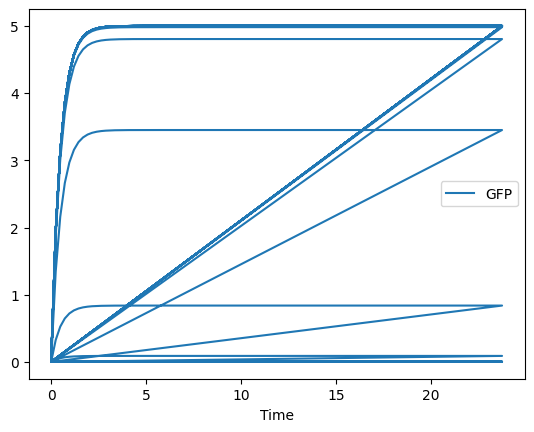

In [7]:
m = assay.measurements
fig,ax = plt.subplots(1,1)
m[m.Signal=='GFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{gfp}')

[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 10]')]

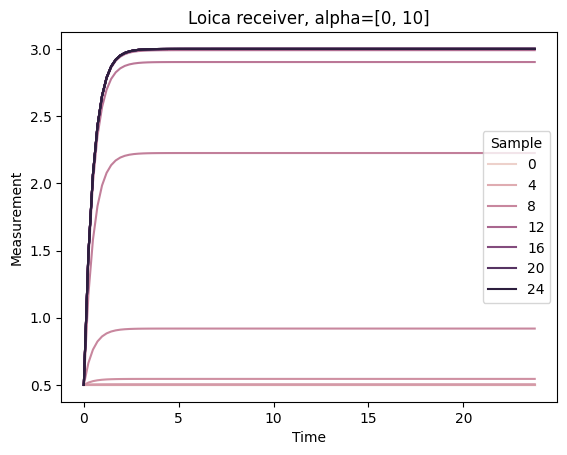

In [19]:
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

## Receiver 2 alpha [0,100]

In [20]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec2=lc.Receiver(input=C4_supp, output=gfp, alpha=[0,100], K=0.01, n=2)
genetwork.add_operator(C4_Rec2)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec2.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()

100%|██████████| 100.0/100 [00:10<00:00,  9.32it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 100]')]

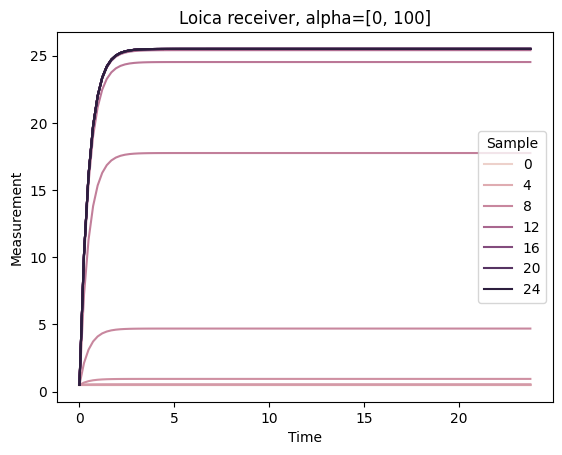

In [21]:
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

## Receiver 3 alpha [100,200]

In [22]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec3=lc.Receiver(input=C4_supp, output=gfp, alpha=[100,200], K=0.01, n=2)
genetwork.add_operator(C4_Rec3)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec3.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()

100%|██████████| 100.0/100 [00:11<00:00,  8.91it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[100, 200]')]

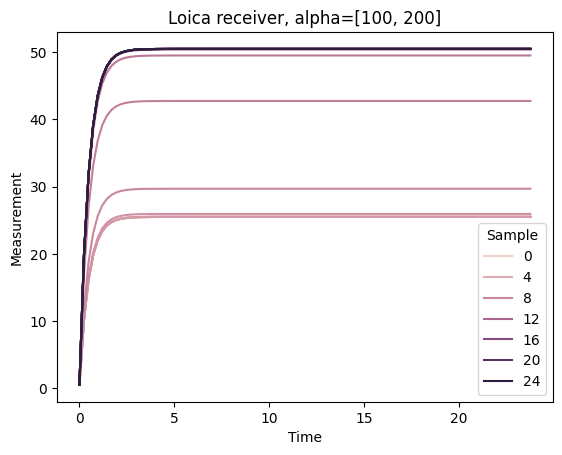

In [23]:
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

## Receiver 1 alpha [0,10] Gompertz

### Define metabolism

In [25]:
def growth_rate(t):
    return lc.gompertz_growth_rate(t, 0.01, 1, 1, 4)

def biomass(t):
    return lc.gompertz(t, 0.01, 1, 1, 4)

100%|██████████| 100.0/100 [00:11<00:00,  8.67it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 10]')]

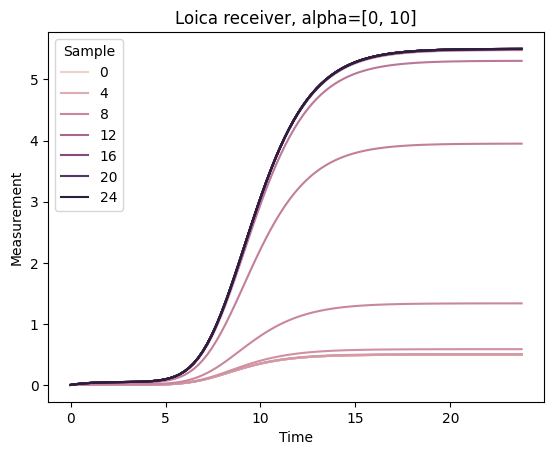

In [26]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec1=lc.Receiver(input=C4_supp, output=gfp, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec1)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec1.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### rec not

100%|██████████| 100.0/100 [00:10<00:00,  9.50it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 10]. not alpha=[4.276875167, 0.289281104]')]

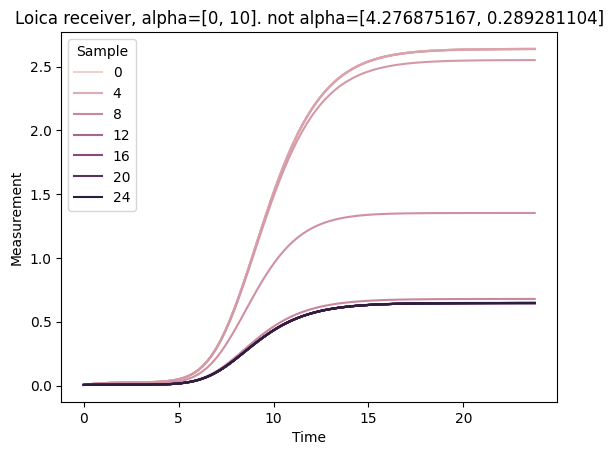

In [55]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec1=lc.Receiver(input=C4_supp, output=amer, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec1)
genetwork.add_regulator(amer)

Reg_amer_NOT_gfp=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_gfp)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec1.alpha}, not alpha={Reg_amer_NOT_gfp.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### rec not not

100%|██████████| 100.0/100 [00:10<00:00,  9.46it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 10]. not1 alpha=[4.276875167, 0.289281104], not2 alpha=[2.797014815, 0.040842627]')]

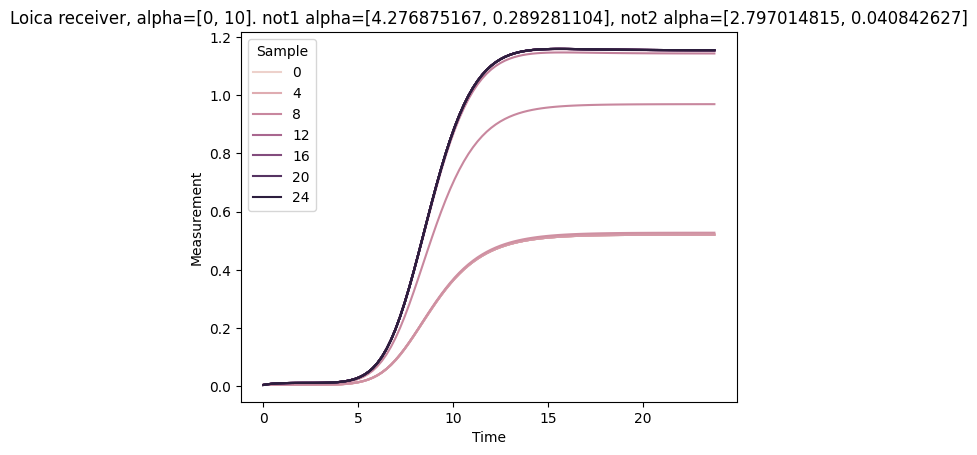

In [59]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec1=lc.Receiver(input=C4_supp, output=amer, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec1)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec1.alpha}, not1 alpha={Reg_amer_NOT_beti.alpha}, not2 alpha={Reg_beti_NOT_GFP.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

## Receiver 2 alpha [0,100] Gompertz

100%|██████████| 100.0/100 [00:10<00:00,  9.16it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 100]')]

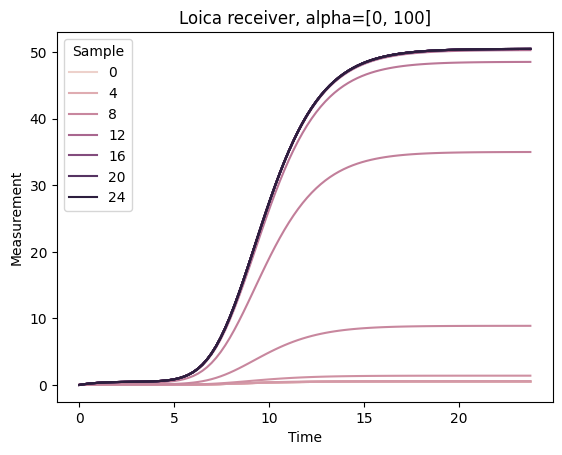

In [27]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec2=lc.Receiver(input=C4_supp, output=gfp, alpha=[0,100], K=0.01, n=2)
genetwork.add_operator(C4_Rec2)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec2.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### rec not

100%|██████████| 100.0/100 [00:11<00:00,  8.76it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 100]')]

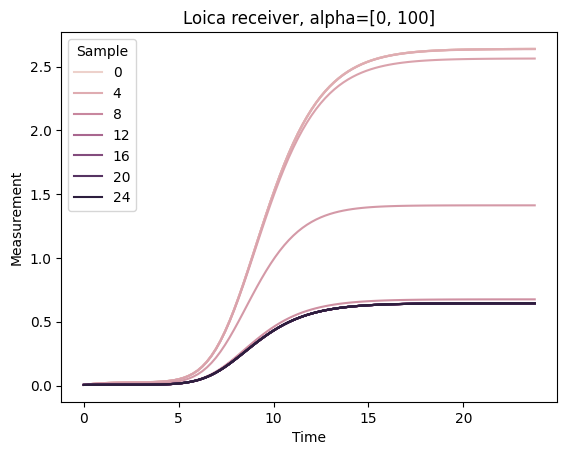

In [60]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec2=lc.Receiver(input=C4_supp, output=amer, alpha=[0,100], K=0.01, n=2)
genetwork.add_operator(C4_Rec2)
genetwork.add_regulator(amer)

Reg_amer_NOT_gfp=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_gfp)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec2.alpha}, not alpha={Reg_amer_NOT_gfp.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### rec not not

100%|██████████| 100.0/100 [00:11<00:00,  8.43it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[0, 100], not1 alpha=[4.276875167, 0.289281104], not2 alpha=[2.797014815, 0.040842627]')]

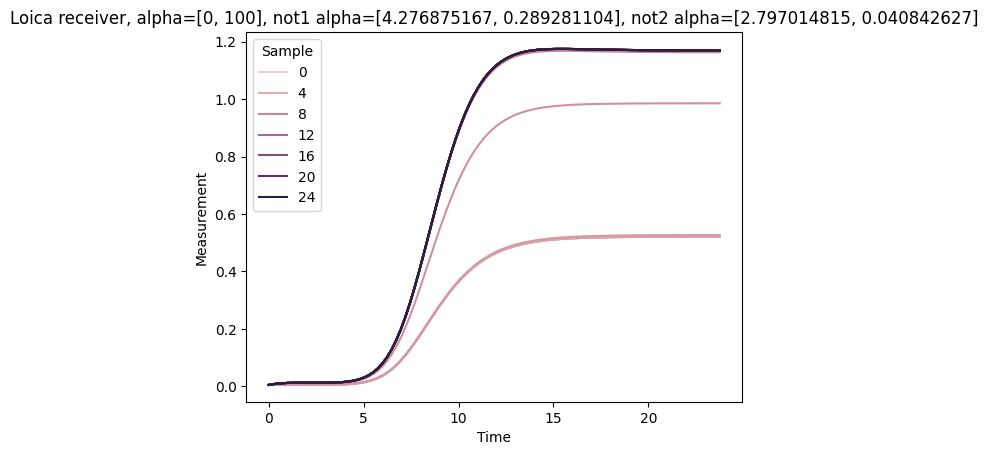

In [65]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec2=lc.Receiver(input=C4_supp, output=amer, alpha=[0,100], K=0.01, n=2)
genetwork.add_operator(C4_Rec2)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec2.alpha}, not1 alpha={Reg_amer_NOT_beti.alpha}, not2 alpha={Reg_beti_NOT_GFP.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

## Receiver 3 alpha [100,200] Gompertz

100%|██████████| 100.0/100 [00:10<00:00,  9.28it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[100, 200]')]

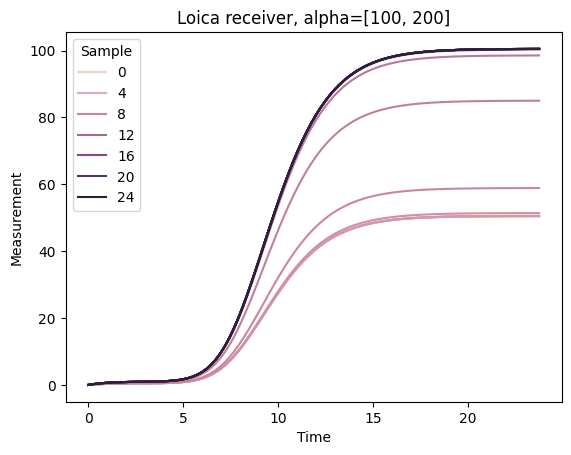

In [28]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec3=lc.Receiver(input=C4_supp, output=gfp, alpha=[100,200], K=0.01, n=2)
genetwork.add_operator(C4_Rec3)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec3.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### rec not

100%|██████████| 100.0/100 [00:10<00:00,  9.51it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[100, 200], not alpha=[4.276875167, 0.289281104]')]

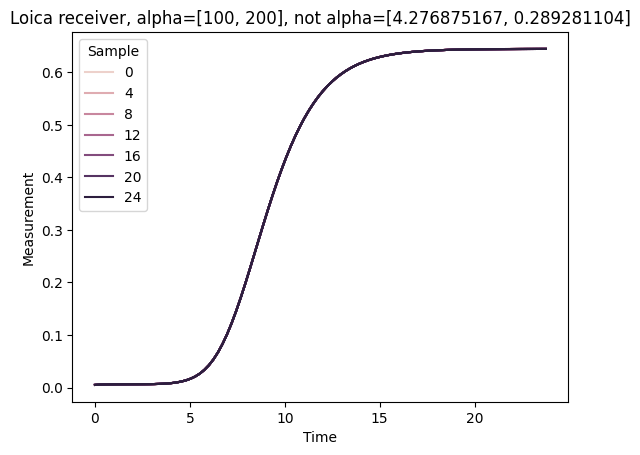

In [64]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec3=lc.Receiver(input=C4_supp, output=amer, alpha=[100,200], K=0.01, n=2)
genetwork.add_operator(C4_Rec3)
genetwork.add_regulator(amer)

Reg_amer_NOT_gfp=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_gfp)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec3.alpha}, not alpha={Reg_amer_NOT_gfp.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### rec not not

100%|██████████| 100.0/100 [00:10<00:00,  9.28it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[100, 200], not1 alpha=[4.276875167, 0.289281104], not2 alpha=[2.797014815, 0.040842627]')]

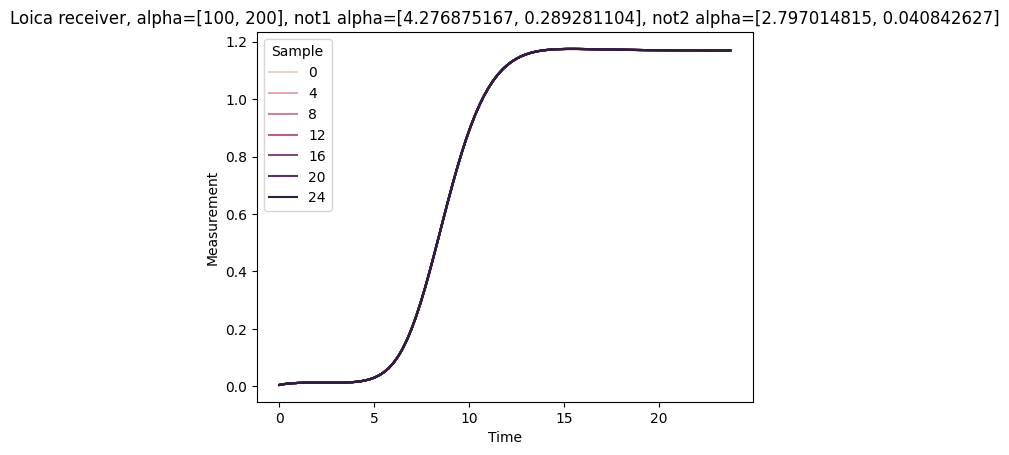

In [66]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec3=lc.Receiver(input=C4_supp, output=amer, alpha=[100,200], K=0.01, n=2)
genetwork.add_operator(C4_Rec3)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec3.alpha}, not1 alpha={Reg_amer_NOT_beti.alpha}, not2 alpha={Reg_beti_NOT_GFP.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

BetI not GFP

100%|██████████| 100.0/100 [00:11<00:00,  8.79it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[100, 200], not1 alpha=[4.276875167, 0.289281104], not2 alpha=[2.797014815, 0.040842627]')]

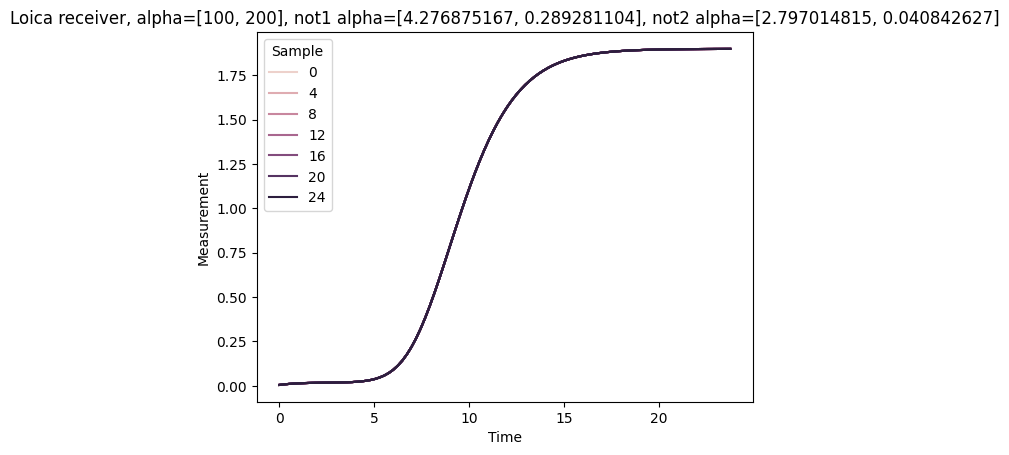

In [69]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)
genetwork.add_regulator([amer, beti])

Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator(Reg_beti_NOT_GFP)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica receiver, alpha={C4_Rec3.alpha}, not1 alpha={Reg_amer_NOT_beti.alpha}, not2 alpha={Reg_beti_NOT_GFP.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

AmeR not GFP

100%|██████████| 100.0/100 [00:10<00:00,  9.74it/s]


[Text(0.5, 1.0, 'Loica receiver, alpha=[100, 200], not1 alpha=[4.276875167, 0.289281104], not2 alpha=[2.797014815, 0.040842627]')]

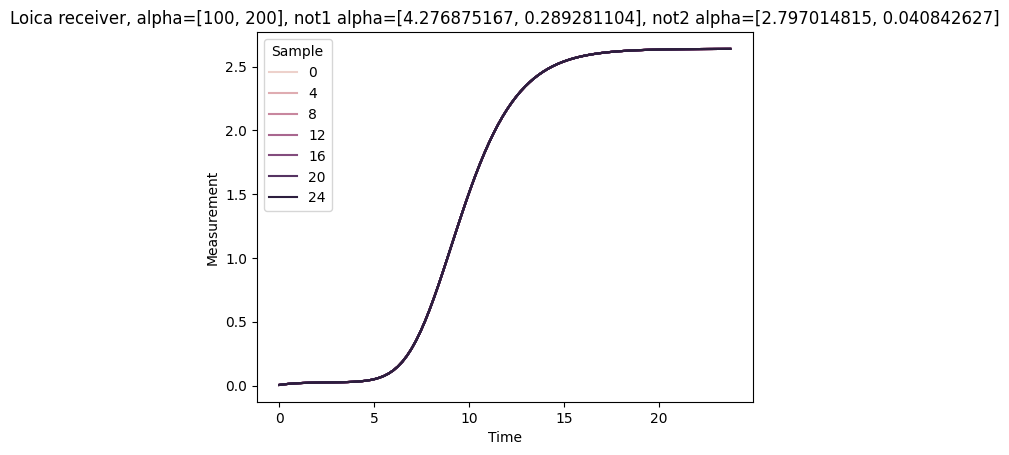

In [68]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_gfp=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_gfp)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica not1 alpha={Reg_amer_NOT_gfp.alpha}',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=assay.measurements, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

## Inverter AmeR NOT GFP

In [51]:
def growth_rate(t):
    return lc.gompertz_growth_rate(t, 0.01, 1, 1, 4)

def biomass(t):
    return lc.gompertz(t, 0.01, 1, 1, 4)

100%|██████████| 100.0/100 [00:10<00:00,  9.34it/s]


[Text(0.5, 1.0, 'Loica Inverter AmeR NOT BetI alpha=[3.8, 0.2]')]

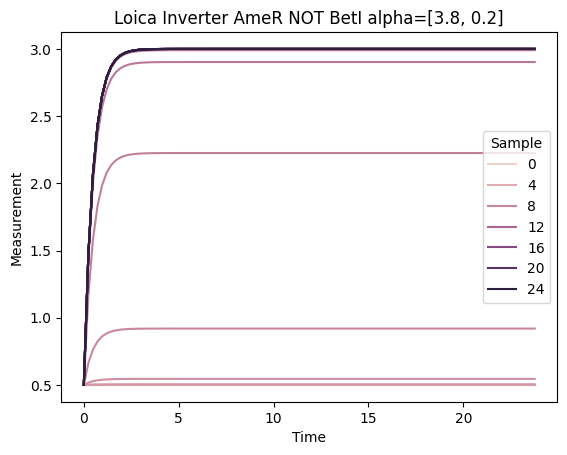

In [52]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
amer = lc.Regulator(name='AmeR', degradation_rate=1)
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec=lc.Receiver(input=C4_supp, output=amer, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec)
genetwork.add_regulator(amer)

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_beti)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica Inverter AmeR NOT BetI alpha={Reg_amer_NOT_beti.alpha}',
              description='Simulated inverter generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### Cello parameters

100%|██████████| 100.0/100 [00:10<00:00,  9.34it/s]


[Text(0.5, 1.0, 'Loica Inverter AmeR NOT BetI alpha=[3.8, 0.2]')]

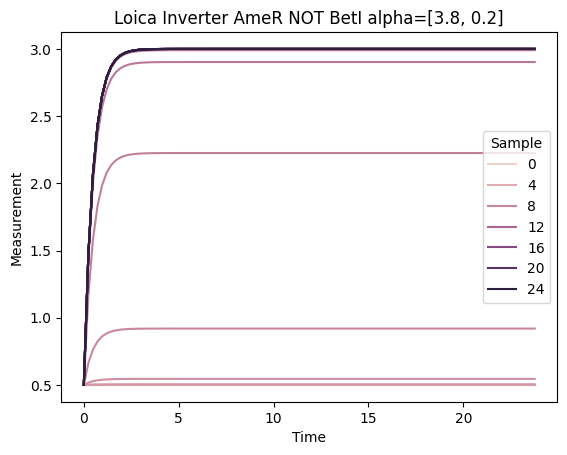

In [47]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
amer = lc.Regulator(name='AmeR', degradation_rate=1)
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec=lc.Receiver(input=C4_supp, output=amer, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec)
genetwork.add_regulator(amer)

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=gfp, alpha=[NOT_amer_f1[1],NOT_amer_f1[2]], K=NOT_amer_f1[3], n=NOT_amer_f1[4])
genetwork.add_operator(Reg_amer_NOT_beti)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica Inverter AmeR NOT BetI alpha={Reg_amer_NOT_beti.alpha}',
              description='Simulated inverter generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

<AxesSubplot:xlabel='Time', ylabel='Measurement'>

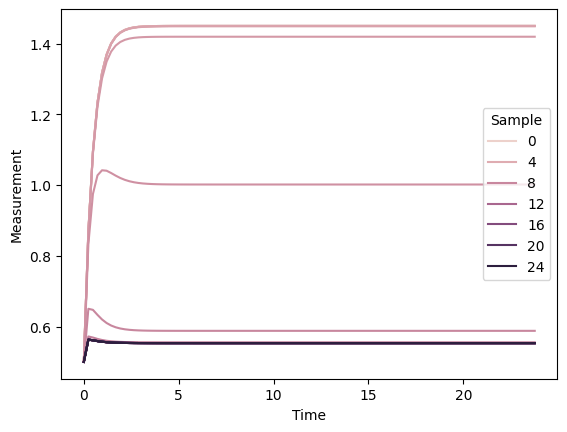

In [130]:
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None)

100%|██████████| 100.0/100 [00:11<00:00,  8.42it/s]


[Text(0.5, 1.0, 'Loica Inverter AmeR NOT BetI alpha=[4.276875167, 0.289281104]')]

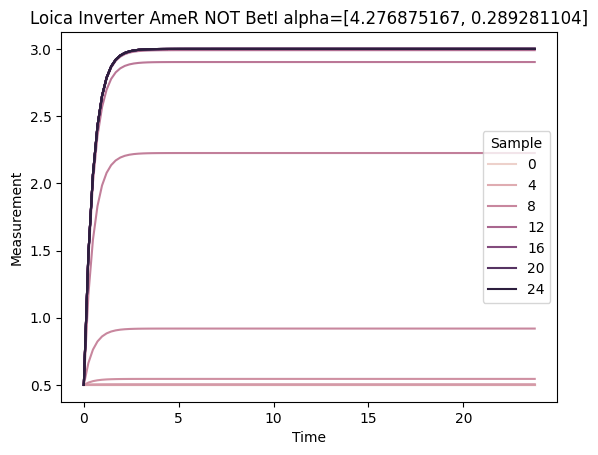

In [35]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
amer = lc.Regulator(name='AmeR', degradation_rate=1)
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec2=lc.Receiver(input=C4_supp, output=amer, alpha=[0,100], K=0.01, n=2)
genetwork.add_operator(C4_Rec2)
genetwork.add_regulator(amer)

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_beti)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica Inverter AmeR NOT BetI alpha={Reg_amer_NOT_beti.alpha}',
              description='Simulated inverter generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

100%|██████████| 100.0/100 [00:10<00:00,  9.54it/s]


[Text(0.5, 1.0, 'Loica Inverter AmeR NOT BetI alpha=[4.276875167, 0.289281104]')]

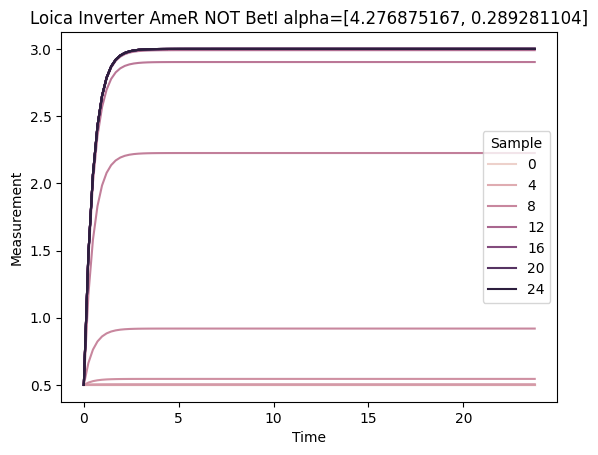

In [36]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
amer = lc.Regulator(name='AmeR', degradation_rate=1)
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec3=lc.Receiver(input=C4_supp, output=amer, alpha=[100,200], K=0.01, n=2)
genetwork.add_operator(C4_Rec3)
genetwork.add_regulator(amer)

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=gfp, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
genetwork.add_operator(Reg_amer_NOT_beti)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name=f'Loica Inverter AmeR NOT BetI alpha={Reg_amer_NOT_beti.alpha}',
              description='Simulated inverter generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

### Double inverter AmeR BetI

100%|██████████| 100.0/100 [00:10<00:00,  9.39it/s]


[Text(0.5, 1.0, 'Loica double inverter AmeR BetI')]

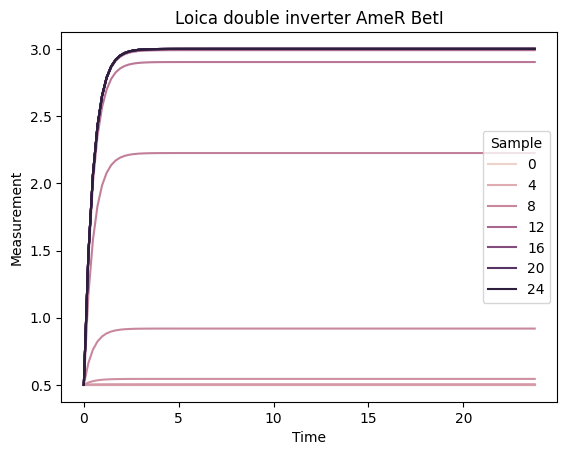

In [37]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec=lc.Receiver(input=C4_supp, output=amer, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name='Loica double inverter AmeR BetI',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

100%|██████████| 100.0/100 [00:12<00:00,  8.33it/s]


[Text(0.5, 1.0, 'Loica double inverter AmeR BetI')]

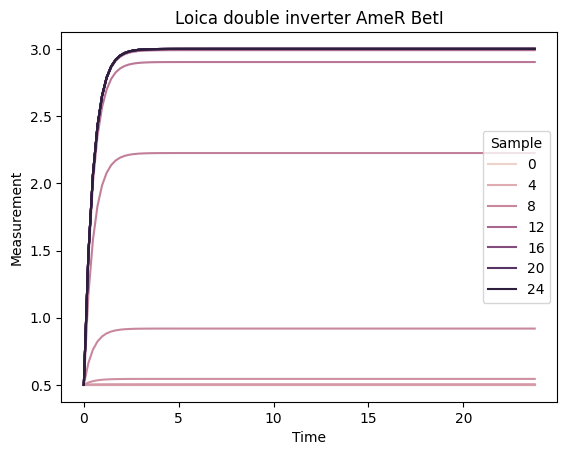

In [38]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec=lc.Receiver(input=C4_supp, output=amer, alpha=[0,100], K=0.01, n=2)
genetwork.add_operator(C4_Rec)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name='Loica double inverter AmeR BetI',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

100%|██████████| 100.0/100 [00:10<00:00,  9.40it/s]


[Text(0.5, 1.0, 'Loica double inverter AmeR BetI')]

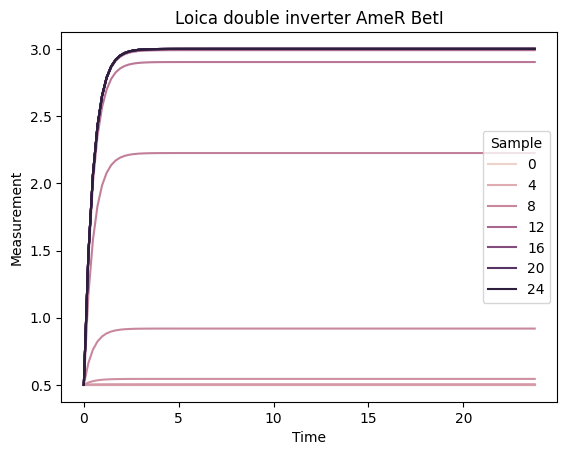

In [39]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec=lc.Receiver(input=C4_supp, output=amer, alpha=[1000,200], K=0.01, n=2)
genetwork.add_operator(C4_Rec)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name='Loica double inverter AmeR BetI',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

<AxesSubplot:xlabel='Time'>

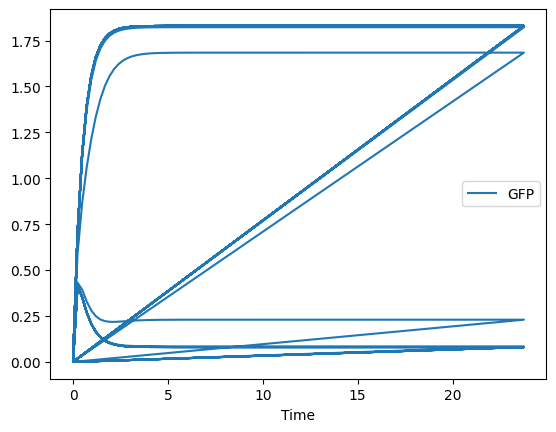

In [114]:
m = assay.measurements
fig,ax = plt.subplots(1,1)
m[m.Signal=='GFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{gfp}')

In [115]:
m

,Time,Signal_id,Signal,Measurement,Sample
0,0.00,0.0,GFP,0.000000,0.0
1,0.00,0.0,Biomass,1.000000,0.0
2,0.24,0.0,GFP,0.415870,0.0
3,0.24,0.0,Biomass,1.000000,0.0
4,0.48,0.0,GFP,0.352673,0.0
...,...,...,...,...,...
4995,23.28,0.0,Biomass,1.000000,24.0
4996,23.52,0.0,GFP,1.829430,24.0
4997,23.52,0.0,Biomass,1.000000,24.0
4998,23.76,0.0,GFP,1.829430,24.0


<AxesSubplot:xlabel='Time', ylabel='Measurement'>

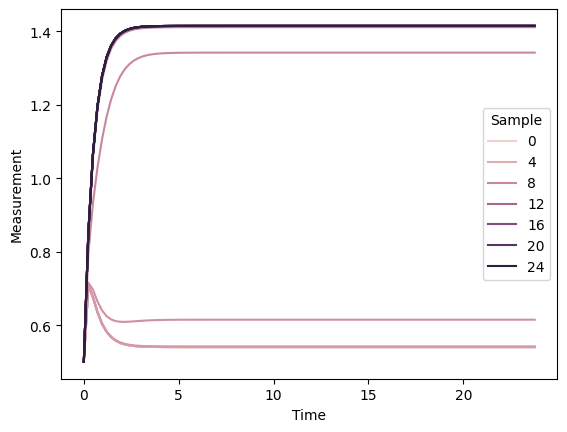

In [124]:
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None)

## Double inverter 2

100%|██████████| 100.0/100 [00:10<00:00,  9.43it/s]


[Text(0.5, 1.0, 'Loica receiver1')]

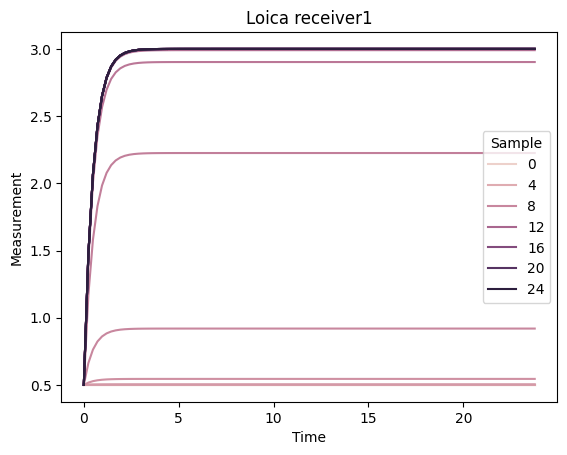

In [49]:
genetwork = lc.GeneticNetwork(vector=0)
C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

C4_Rec=lc.Receiver(input=C4_supp, output=amer, alpha=[0,10], K=0.01, n=2)
genetwork.add_operator(C4_Rec)
genetwork.add_regulator([amer, beti])

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_amer_f1[1],NOT_amer_f1[2]], K=NOT_amer_f1[3], n=NOT_amer_f1[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=gfp, alpha=[NOT_beti_e1[1],NOT_beti_e1[2]], K=NOT_beti_e1[3], n=NOT_beti_e1[4])
genetwork.add_operator([Reg_amer_NOT_beti, Reg_beti_NOT_GFP])

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-6, 6, 24))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name='Loica receiver1',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()
sns.lineplot(data=m, x='Time', y='Measurement', hue='Sample', errorbar=None).set(title=assay.name)

In [34]:
genetwork = lc.GeneticNetwork(vector=0)

C4_Rec=lc.Receiver(input=C4_supp, output=gfp, alpha=[0.001,1000], K=1, n=2)
genetwork.add_operator(C4_Rec)

Reg_amer_NOT_beti=lc.Hill1(input=amer, output=beti, alpha=[NOT_F1_AmeR[1],NOT_F1_AmeR[2]], K=NOT_F1_AmeR[3], n=NOT_F1_AmeR[4])
Reg_beti_NOT_GFP=lc.Hill1(input=beti, output=amer, alpha=[NOT_E1_BetI[1],NOT_E1_BetI[2]], K=NOT_E1_BetI[3], n=NOT_E1_BetI[4])
genetwork.add_operator([Reg_amer_NOT_beti,Reg_beti_NOT_GFP])
genetwork.add_regulator([amer,beti])

C4_supp = lc.Supplement(name='C4')
gfp = lc.Reporter(name='GFP', degradation_rate=1, signal_id=0)
genetwork.add_reporter(gfp)

metab = lc.SimulatedMetabolism('SimMetab',biomass, growth_rate)

# Create list of samples    
samples = []
concs = np.append(0, np.logspace(-3, 3, 12))
for conc in concs:
    for _ in range(1):
        sample = lc.Sample(genetic_network=genetwork, 
                    metabolism=metab,
                    media=0,
                    strain=0)
        # Add AHL to samples at given concentration
        sample.set_supplement(C4_supp, conc)
        samples.append(sample)

assay = lc.Assay(samples, 
              n_measurements=100, 
              interval=0.24,
              name='Loica receiver1',
              description='Simulated receiver generated by loica',
              biomass_signal_id=0
             )
assay.run()

100%|██████████| 100.0/100 [00:06<00:00, 16.34it/s]             


<AxesSubplot:xlabel='Time'>

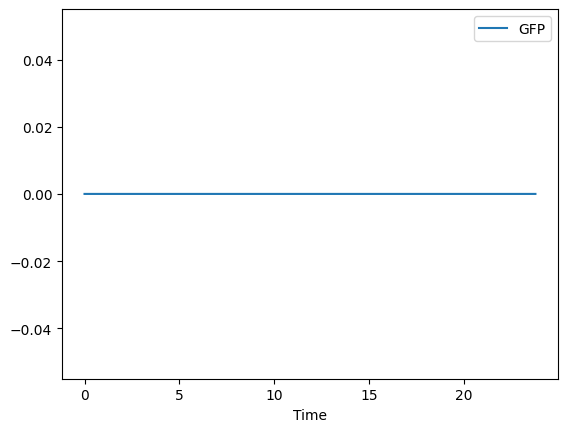

In [35]:
m = assay.measurements
fig,ax = plt.subplots(1,1)
m[m.Signal=='GFP'].plot(x='Time', y='Measurement', ax=ax, label=f'{gfp}')

In [ ]:
Reg_betl_NOT_phif=lc.Hill1(input=amtr, output=NOT_N1_LmrA, alpha=[op[2][1],op[2][2]]*1000, K=op[2][3]*1000, n=op[2][4])
Reg_phif_NOT_gfp=


In [ ]:
Reg_phif_NOT_amer=lc.Hill1(input=beti, output=NOT_E2_BetI, alpha=[op[3][1],op[3][2]]*1000, K=op[3][3]*1000, n=op[3][4])
Reg_amer_NOT_gfp=


In [ ]:
Reg_amtr_NOT_phif=lc.Hill1(input=phif, output=NOT_P2_PhlF, alpha=[op[4][1],op[4][2]]*1000, K=op[4][3]*1000, n=op[4][4])
Reg_phif_NOT_gfp=

In [ ]:
Reg_phif_NOT_betl=lc.Hill1(input=phif, output=NOT_P2_PhlF, alpha=[op[4][1],op[4][2]]*1000, K=op[4][3]*1000, n=op[4][4])
Reg_betl_NOT_GFP=

In [ ]:
Reg_betl_NOT_amtr=lc.Hill1(input=phif, output=NOT_P2_PhlF, alpha=[op[4][1],op[4][2]]*1000, K=op[4][3]*1000, n=op[4][4])
Reg_amtr_NOT_GFP=